# Análise Exploratória de Dados (EDA) - Olist E-commerce

## Objetivo

Este projeto tem como objetivo realizar uma Análise Exploratória de Dados (EDA) utilizando o conjunto de dados público da Olist, buscando compreender o comportamento das vendas, identificar padrões de consumo e analisar a satisfação dos clientes.

## Perguntas de negócio

- Qual é a receita total do período?
- Qual é o ticket médio dos pedidos?
- Quais categorias geram mais receita?
- Como os clientes avaliam cada categoria?
- Existe sazonalidade nas vendas?

## Ferramentas utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use("ggplot")
sns.set_theme()

In [6]:
from pathlib import Path

# Caminho para a pasta de dados
DATA_PATH = Path("../data")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")

In [12]:
customers.head()
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [13]:
orders.head()
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [14]:
items.head()
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [15]:
products.head()
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [16]:
reviews.head()
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [17]:
# Valores ausentes em cada tabela
print("Customers")
print(customers.isnull().sum())

print("\nOrders")
print(orders.isnull().sum())

print("\nItems")
print(items.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

print("\nReviews")
print(reviews.isnull().sum())

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm         

In [18]:
# Valores ausentes
for nome, df in {
    "Customers": customers,
    "Orders": orders,
    "Items": items,
    "Products": products,
    "Reviews": reviews
}.items():
    print(f"\n==== {nome} ====")
    print(df.isnull().sum())


==== Customers ====
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

==== Orders ====
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

==== Items ====
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

==== Products ====
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm 

In [19]:
print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Items:", items.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Reviews:", reviews.duplicated().sum())

Customers: 0
Orders: 0
Items: 0
Products: 0
Reviews: 0


In [20]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [21]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [22]:
df = (
    items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
    .merge(
        orders[
            [
                "order_id",
                "customer_id",
                "order_purchase_timestamp"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

In [23]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score,customer_id,order_purchase_timestamp,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,5.0,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,4.0,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,5.0,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,4.0,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,5.0,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,SP


In [24]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score,customer_id,order_purchase_timestamp,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,5.0,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,4.0,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,5.0,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,4.0,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,5.0,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,SP


In [25]:
df["receita"] = df["price"] + df["freight_value"]

df["ano"] = df["order_purchase_timestamp"].dt.year

df["mes"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

In [26]:
receita_total = df["receita"].sum()

ticket_medio = df["receita"].mean()

pedidos = df["order_id"].nunique()

nota_media = df["review_score"].mean()

print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Ticket médio: R$ {ticket_medio:.2f}")
print(f"Pedidos: {pedidos}")
print(f"Nota média: {nota_media:.2f}")

Receita total: R$ 15,915,872.32
Ticket médio: R$ 140.46
Pedidos: 98666
Nota média: 4.03


## Receita por Categoria

Este gráfico apresenta as categorias responsáveis pelo maior faturamento da empresa.

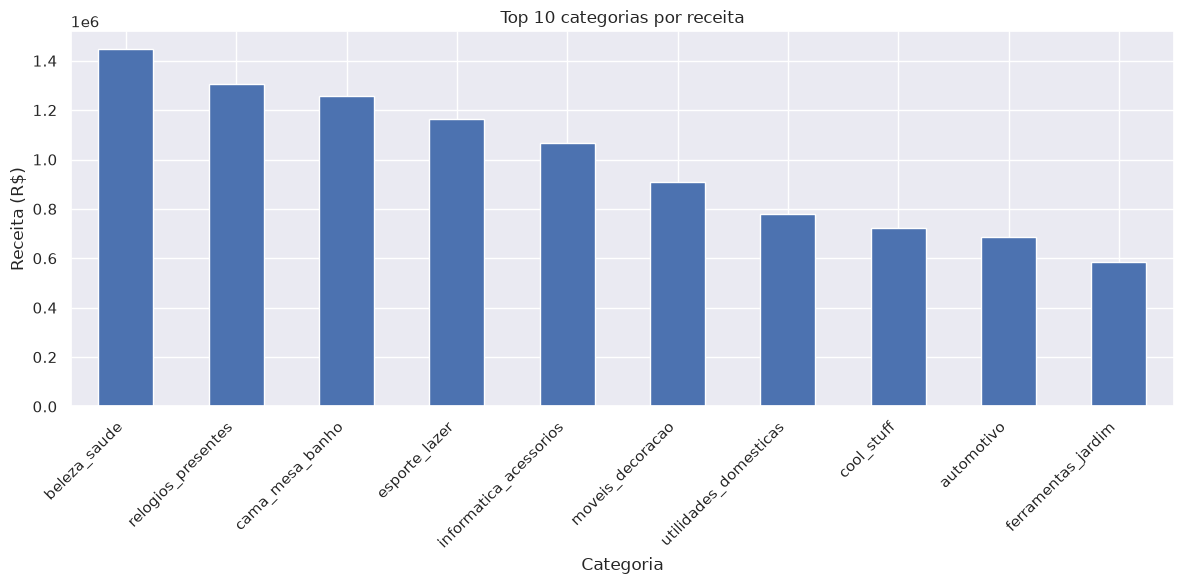

In [52]:
receita_categoria = (
    df.groupby("product_category_name")["receita"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

receita_categoria.plot(kind="bar")

plt.title("Top 10 categorias por receita")
plt.xlabel("Categoria")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../imagens/receita_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Observa-se que poucas categorias concentram grande parte da receita, indicando uma distribuição desigual do faturamento entre os produtos.

## Avaliação por Categoria

Esta análise investiga o nível de satisfação dos clientes em relação às categorias de produtos.

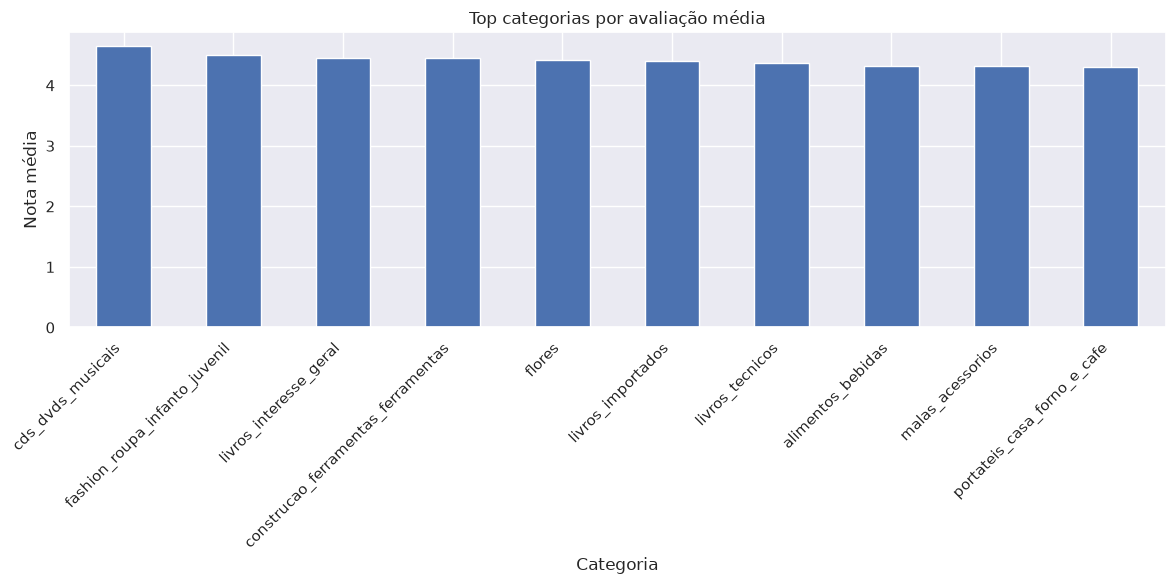

In [53]:
avaliacao_categoria = (
    df.groupby("product_category_name")["review_score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

avaliacao_categoria.plot(kind="bar")

plt.title("Top categorias por avaliação média")
plt.xlabel("Categoria")
plt.ylabel("Nota média")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../imagens/avaliacao_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Grande parte das categorias apresenta avaliações elevadas, indicando boa experiência dos consumidores.

## Evolução dos Pedidos ao Longo do Tempo

Nesta etapa é analisado o comportamento temporal das vendas.

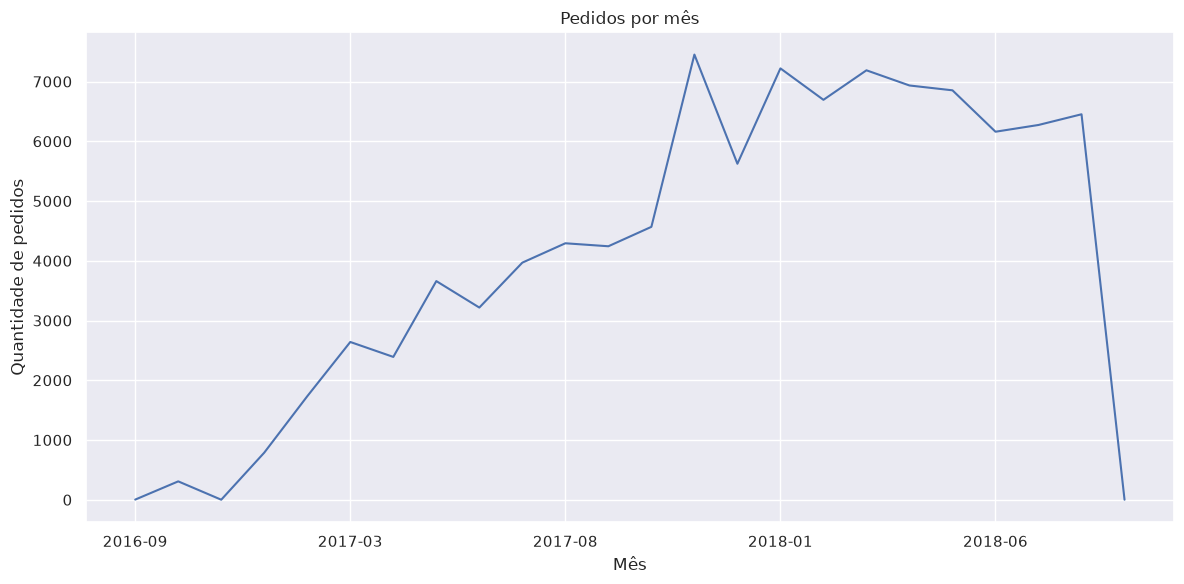

In [54]:
pedidos_mes = (
    df.groupby("mes")["order_id"]
      .nunique()
)

plt.figure(figsize=(12,6))

pedidos_mes.plot()

plt.title("Pedidos por mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade de pedidos")

plt.tight_layout()
plt.savefig("../imagens/sazonalidade_pedidos.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Foi observado um crescimento significativo no número de pedidos durante o período da Black Friday, evidenciando a influência de campanhas promocionais sobre o volume de vendas.

## Distribuição das Avaliações

O objetivo desta análise é compreender como os clientes avaliam suas compras.

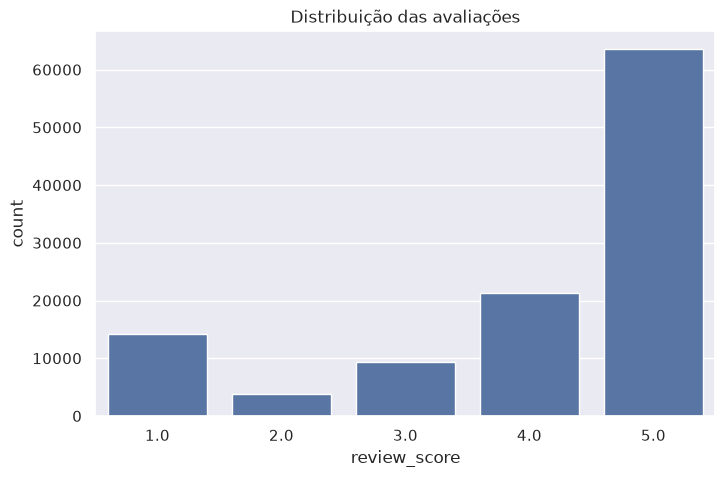

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="review_score")

plt.title("Distribuição das avaliações")

plt.savefig("../imagens/distribuicao_avaliacoes.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

A maior parte das avaliações concentra-se nas notas 4 e 5, indicando predominância de clientes satisfeitos.

## Receita versus Avaliação

Este gráfico busca verificar se categorias com maior faturamento também apresentam melhores avaliações dos clientes.

In [31]:
receita_categoria = (
    df.groupby("product_category_name")["receita"]
      .sum()
      .reset_index()
)

avaliacao_categoria = (
    df.groupby("product_category_name")["review_score"]
      .mean()
      .reset_index()
)

final = receita_categoria.merge(
    avaliacao_categoria,
    on="product_category_name"
)

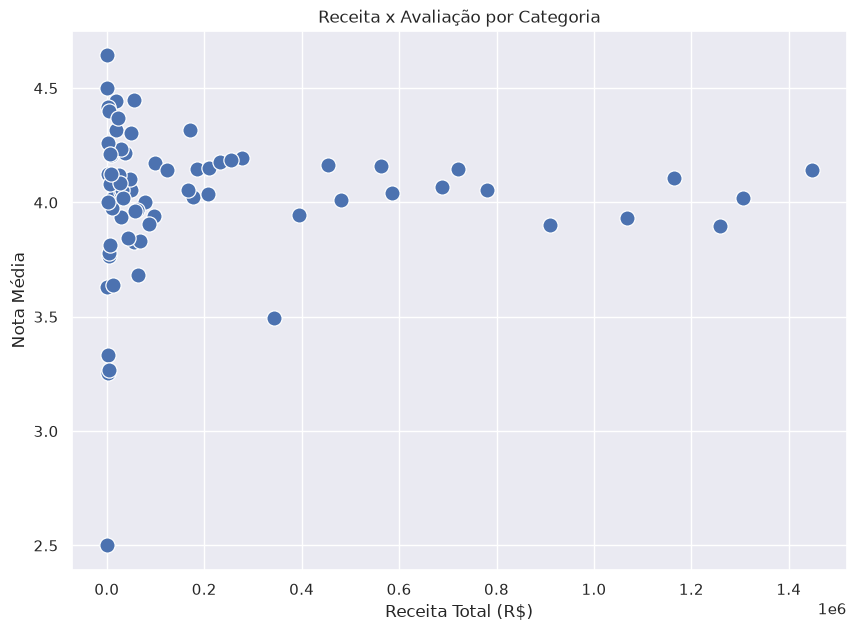

In [56]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=final,
    x="receita",
    y="review_score",
    s=120
)

plt.title("Receita x Avaliação por Categoria")
plt.xlabel("Receita Total (R$)")
plt.ylabel("Nota Média")

plt.savefig("../imagens/receita_vs_avaliacao.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Nem sempre as categorias que geram maior receita apresentam as maiores notas de satisfação, indicando oportunidades de melhoria na experiência do cliente.

## Tempo de Entrega

Nesta etapa é analisada a distribuição do tempo entre a compra e a entrega do pedido ao cliente.

In [33]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [34]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

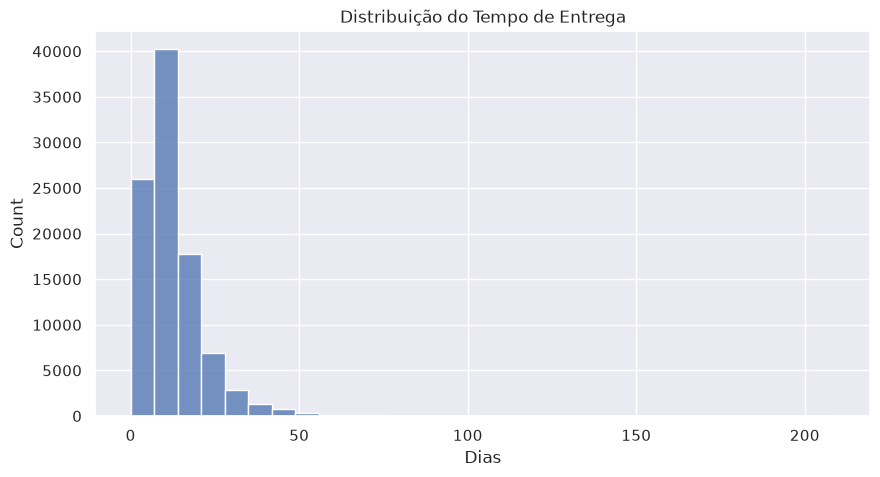

In [57]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["delivery_days"].dropna(),
    bins=30
)

plt.title("Distribuição do Tempo de Entrega")
plt.xlabel("Dias")

plt.savefig("../imagens/tempo_entrega.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

A maior parte das entregas ocorre dentro de um intervalo relativamente curto, embora existam alguns pedidos com prazos significativamente superiores, caracterizando outliers.

## Pedidos por Estado

Esta análise identifica quais estados brasileiros concentram o maior número de pedidos realizados.

In [39]:
pedidos_estado = (
    df.groupby("customer_state")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

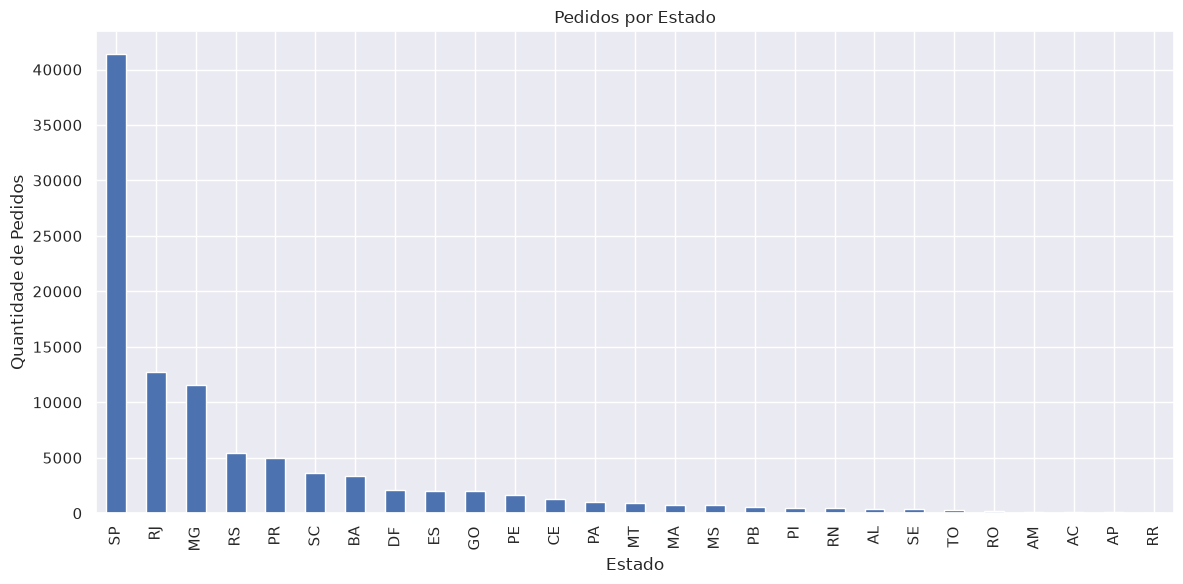

In [58]:
plt.figure(figsize=(12,6))

pedidos_estado.plot(kind="bar")

plt.title("Pedidos por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Pedidos")

plt.tight_layout()
plt.savefig("../imagens/pedidos_estado.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Os estados da região Sudeste concentram a maior parte dos pedidos, refletindo a distribuição do mercado consumidor.

## Ticket por Categoria

Nesta análise é calculado o valor médio gasto por pedido em cada categoria de produto.

In [41]:
ticket_categoria = (
    df.groupby("product_category_name")["receita"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

In [42]:
ticket_categoria = (
    df.groupby("product_category_name")["receita"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

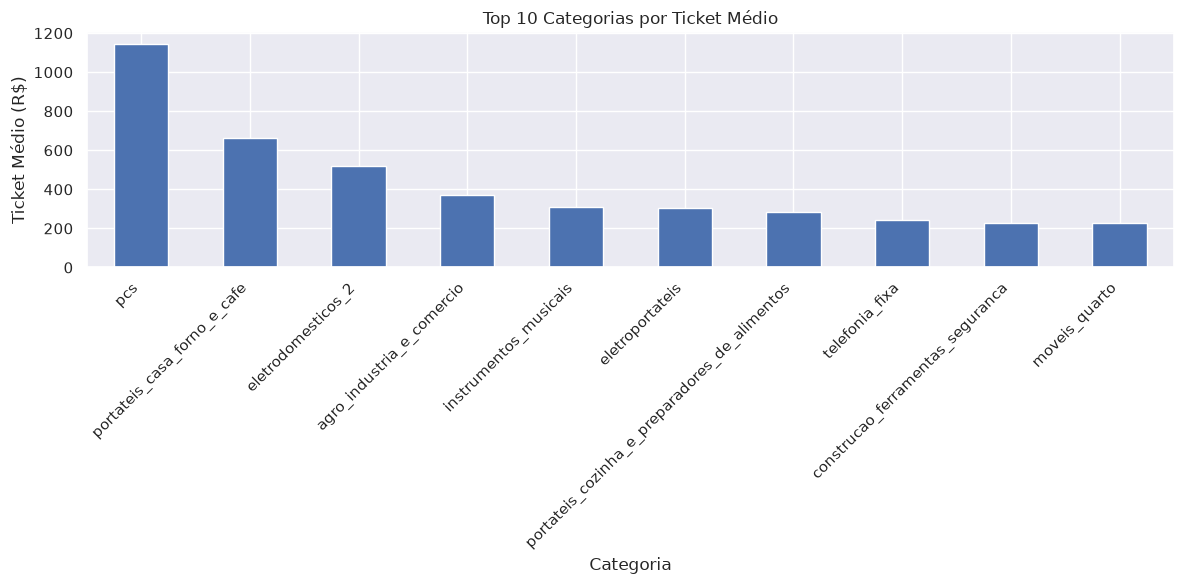

In [59]:
plt.figure(figsize=(12,6))

ticket_categoria.plot(kind="bar")

plt.title("Top 10 Categorias por Ticket Médio")
plt.xlabel("Categoria")
plt.ylabel("Ticket Médio (R$)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../imagens/ticket_medio_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Algumas categorias apresentam ticket médio elevado mesmo sem possuir o maior volume de vendas.

# 📊 Análise Exploratória de Dados - Olist

**Autor:** Mariany Reis

**Ferramentas:** Python | Pandas | NumPy | Matplotlib | Seaborn | Jupyter Notebook

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

---

# 1. Introdução

## Objetivo

Este projeto apresenta uma Análise Exploratória de Dados (EDA) utilizando o conjunto de dados público da Olist, um marketplace brasileiro.

O objetivo deste projeto é explorar os dados de vendas da Olist para identificar padrões de compra, avaliar a satisfação dos clientes e gerar insights que possam apoiar decisões de negócio. Para isso, foram utilizadas técnicas de limpeza, integração, transformação e visualização de dados com Python.

## Perguntas de negócio

Durante a análise, buscamos responder às seguintes perguntas:

Qual é a receita total do e-commerce?
Qual é o ticket médio dos pedidos?
Quais categorias geram maior faturamento?
As categorias mais rentáveis também são as mais bem avaliadas?
Existe sazonalidade nas vendas?
Qual é o tempo médio de entrega dos pedidos?
Quais estados concentram o maior volume de pedidos?

# 2. Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas ao longo da análise.

As principais ferramentas utilizadas são:

- **Pandas:** manipulação e análise de dados.
- **NumPy:** operações matemáticas.
- **Matplotlib:** criação de gráficos.
- **Seaborn:** visualizações estatísticas.
- **Pathlib:** gerenciamento de caminhos para leitura dos arquivos.

# 3. Carregamento dos Dados

Os arquivos do dataset da Olist são carregados em DataFrames separados.

Cada arquivo representa uma parte do processo de vendas:

- Clientes
- Pedidos
- Itens dos pedidos
- Produtos
- Avaliações

Esses dados serão integrados posteriormente para permitir análises mais completas.

# 4. Exploração Inicial

Antes de iniciar qualquer análise, é importante compreender a estrutura dos dados.

Nesta etapa são utilizados os métodos:

- `head()`
- `shape`
- `info()`

Esses comandos permitem identificar:

- quantidade de registros;
- quantidade de colunas;
- tipos de dados;
- estrutura de cada tabela.

# 5. Limpeza e Tratamento

Nesta etapa são verificadas possíveis inconsistências nos dados.

Foram realizadas as seguintes verificações:

- valores ausentes;
- registros duplicados;
- tipos das colunas;
- conversão das colunas de datas para o formato `datetime`.

Esses procedimentos garantem maior confiabilidade para as análises posteriores.

# 6. Integração dos Dados

Como as informações encontram-se distribuídas em diferentes tabelas, foi necessário integrá-las utilizando a função `merge()` do pandas.

Foram relacionadas informações sobre:

- pedidos;
- produtos;
- avaliações;
- clientes.

Ao final desta etapa foi criado um único DataFrame analítico que servirá como base para todas as análises.

# 7. Engenharia de Atributos

Nesta etapa foram criadas novas variáveis para facilitar as análises.

As principais colunas derivadas foram:

- Receita do pedido;
- Ano da compra;
- Mês da compra.

Esses atributos permitem construir indicadores e visualizar tendências temporais.

# 8. Análise Exploratória

Nesta etapa são realizadas análises gráficas para compreender o comportamento das vendas e da satisfação dos clientes.

As análises desenvolvidas incluem:

- Receita por categoria;
- Ticket médio;
- Avaliação média por categoria;
- Receita versus avaliação;
- Evolução dos pedidos ao longo do tempo;
- Distribuição das avaliações;
- Pedidos por estado;
- Tempo médio de entrega.

# 9. Conclusões

## Principais resultados

A análise exploratória permitiu compreender aspectos importantes do desempenho do e-commerce da Olist.

Os principais insights obtidos foram:

- A receita está concentrada em poucas categorias de produtos.
- O ticket médio varia significativamente entre as categorias.
- A maioria das avaliações é positiva, indicando boa satisfação dos clientes.
- O volume de pedidos aumenta durante períodos promocionais, como a Black Friday.
- Os estados da região Sudeste concentram a maior parte das vendas.
- O tempo médio de entrega mostrou-se consistente para operações de e-commerce.

## Considerações finais

Este projeto demonstrou a aplicação de técnicas de limpeza, integração, transformação e visualização de dados utilizando Python e suas principais bibliotecas para análise de dados.

Os resultados obtidos podem servir como apoio para decisões relacionadas a vendas, logística e experiência do cliente.